# Import Python Libraries

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

<h4> Ad click Project </h4>

This is a website data of Customers to understand which customer will click the AD.
This data set contains the following features:

* '`Daily Time Spent on Site`': consumer time on site in minutes
* '`Age`': cutomer age in years
* '`Area Income`': Avg. Income of geographical area of consumer
* '`Daily Internet Usage`': Avg. minutes a day consumer is on the internet
* '`Ad Topic Line`': Headline of the advertisement
* '`City`': City of consumer
* '`Male`': Whether or not consumer was male (0 means no and 1 mean yes)
* '`Country`': Country of consumer
* '`Timestamp`': Time at which consumer clicked on Ad or closed window
* '`Clicked on Ad`': 0 means not click and 1 indicated clicking on Ad

In [13]:
# Import the dataset
df = pd.read_csv("advertising.csv")

##  Data Exploration

In [22]:
# To see the first five rows
df.head()  

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11,0
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02,0
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,2016-03-13 20:35:42,0
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,2016-01-10 02:31:19,0
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,2016-06-03 03:36:18,0


In [24]:
# To see the last five rows
df.tail()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
995,72.97,30,71384.57,208.58,Fundamental modular algorithm,Duffystad,1,Lebanon,2016-02-11 21:49:00,1
996,51.30,45,67782.17,134.42,Grass-roots cohesive monitoring,New Darlene,1,Bosnia and Herzegovina,2016-04-22 02:07:01,1
997,51.63,51,42415.72,120.37,Expanded intangible solution,South Jessica,1,Mongolia,2016-02-01 17:24:57,1
998,55.55,19,41920.79,187.95,Proactive bandwidth-monitored policy,West Steven,0,Guatemala,2016-03-24 02:35:54,0
999,45.01,26,29875.80,178.35,Virtual 5thgeneration emulation,Ronniemouth,0,Brazil,2016-06-03 21:43:21,1


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  1000 non-null   float64
 1   Age                       1000 non-null   int64  
 2   Area Income               1000 non-null   float64
 3   Daily Internet Usage      1000 non-null   float64
 4   Ad Topic Line             1000 non-null   object 
 5   City                      1000 non-null   object 
 6   Male                      1000 non-null   int64  
 7   Country                   1000 non-null   object 
 8   Timestamp                 1000 non-null   object 
 9   Clicked on Ad             1000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 78.3+ KB


In [28]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Daily Time Spent on Site,1000.0,NaN,NaN,NaN,65.0002,15.853615,32.6,51.36,68.215,78.5475,91.43
Age,1000.0,NaN,NaN,NaN,36.009,8.785562,19.0,29.0,35.0,42.0,61.0
Area Income,1000.0,NaN,NaN,NaN,55000.00008,13414.634022,13996.5,47031.8025,57012.3,65470.635,79484.8
Daily Internet Usage,1000.0,NaN,NaN,NaN,180.0001,43.902339,104.78,138.83,183.13,218.7925,269.96
Ad Topic Line,1000,1000,Cloned 5thgeneration orchestration,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,1000,969,Lisamouth,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Male,1000.0,NaN,NaN,NaN,0.481,0.499889,0.0,0.0,0.0,1.0,1.0
Country,1000,237,France,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Timestamp,1000,1000,2016-03-27 00:53:11,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Clicked on Ad,1000.0,NaN,NaN,NaN,0.5,0.50025,0.0,0.0,0.5,1.0,1.0


In [30]:
df.nunique()

Daily Time Spent on Site     900
Age                           43
Area Income                 1000
Daily Internet Usage         966
Ad Topic Line               1000
City                         969
Male                           2
Country                      237
Timestamp                   1000
Clicked on Ad                  2
dtype: int64

## Check Duplicates

In [40]:
print(df.duplicated().value_counts())
df.drop_duplicates(inplace = True)
print(len(df))

False    1000
Name: count, dtype: int64
1000


## Checking Missing Values

In [43]:
df.isnull().sum()

Daily Time Spent on Site    0
Age                         0
Area Income                 0
Daily Internet Usage        0
Ad Topic Line               0
City                        0
Male                        0
Country                     0
Timestamp                   0
Clicked on Ad               0
dtype: int64

## Basic Data Exploration Results
Based on the basic exploration, this dataset have 1000 rows and 10 columns also we see there are no missing values in this dataset and no duplicate rows.

#### The selected columns in this step are not final, further study will be done and then a final list will be created
- Daily Time Spent on Site: Continuous
- Age: Continuous
- Area Income: Continuous
- Daily Internet Usage: Continuous
- Ad Topic Line: Descriptive, most of them are unique we can drop it
- City: Categorical, similary for this column we can drop it.
- Male: Categorical but it's represent as numerical.
- Country: Categorical, although this column have less unique value but respective of total rows of data we need to drop it.
- Timestamp: Descriptive
- Clicked on Ad: Categorical. This is the Target Variable!

In [46]:
df=df[['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage', 'Male', 'Timestamp', 'Clicked on Ad']]

# Transform the Data Types of the columns

In [49]:
df["Male"]=df["Male"].astype("O")

In [51]:
df["Timestamp"]=pd.to_datetime(df["Timestamp"])

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Daily Time Spent on Site  1000 non-null   float64       
 1   Age                       1000 non-null   int64         
 2   Area Income               1000 non-null   float64       
 3   Daily Internet Usage      1000 non-null   float64       
 4   Male                      1000 non-null   object        
 5   Timestamp                 1000 non-null   datetime64[ns]
 6   Clicked on Ad             1000 non-null   int64         
dtypes: datetime64[ns](1), float64(3), int64(2), object(1)
memory usage: 54.8+ KB


# Feature Engineering

In [56]:
# Extract day, month and year from timestamp
df["Day"]=df["Timestamp"].dt.day_name()
df["Month"]=df["Timestamp"].dt.month_name()
df["Year"]=df["Timestamp"].dt.year

In [58]:
df.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male,Timestamp,Clicked on Ad,Day,Month,Year
0,68.95,35,61833.90,256.09,0,2016-03-27 00:53:11,0,Sunday,March,2016
1,80.23,31,68441.85,193.77,1,2016-04-04 01:39:02,0,Monday,April,2016
2,69.47,26,59785.94,236.50,0,2016-03-13 20:35:42,0,Sunday,March,2016
3,74.15,29,54806.18,245.89,1,2016-01-10 02:31:19,0,Sunday,January,2016
4,68.37,35,73889.99,225.58,0,2016-06-03 03:36:18,0,Friday,June,2016


In [60]:
# now drop Timestamp
df.drop("Timestamp",axis=1,inplace=True)

## Target Variable

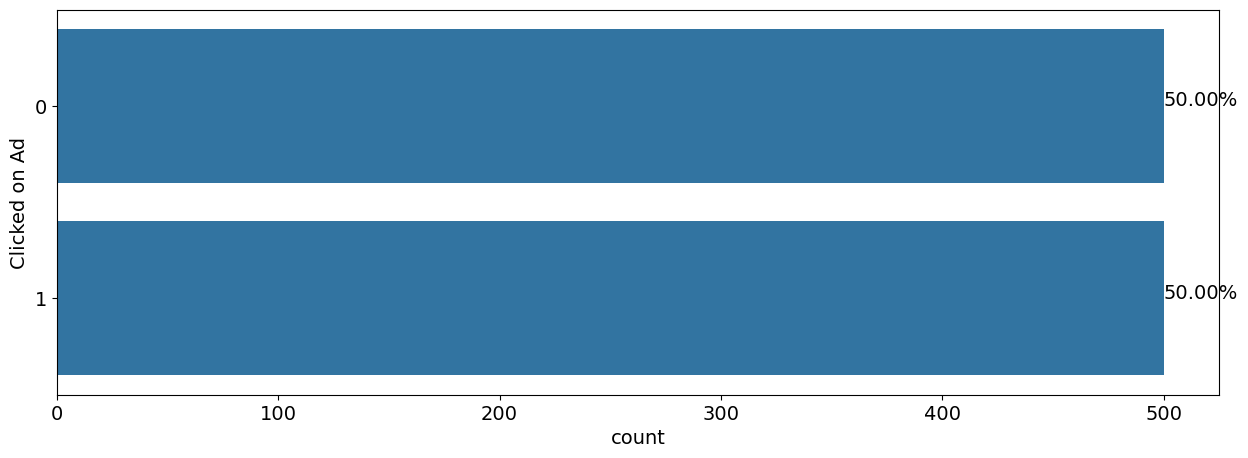

In [63]:
plt.figure(figsize=(15,5))
plt.rc("font", size=14)
ax = sns.countplot(y ='Clicked on Ad',data=df)
total = len(df['Clicked on Ad'])
for p in ax.patches:
    percentage = '{:.2f}%'.format(100 * p.get_width()/total)
    x = p.get_x() + p.get_width() + 0.02
    y = p.get_y() + p.get_height()/2
    ax.annotate(percentage, (x, y))
plt.rc("font", size=14)
plt.show()

- Over here we see that class 0 have 500 rows and class 1 have 500 rows.
- After checking the percentage of those class it didn't imply that this data is imbalanced.

# Exploratory Data Analysis

In [69]:
# Create a variables list based on their types.
categorical_col=[]
numerical_col=[]

for col in df.columns.difference(['Clicked on Ad']):
    if df[col].dtype =="object":
        categorical_col.append(col)
    elif df[col].dtype =="int64" or df[col].dtype =="float64":
        numerical_col.append(col)

In [71]:
categorical_col

['Day', 'Male', 'Month']

In [73]:
numerical_col

['Age', 'Area Income', 'Daily Internet Usage', 'Daily Time Spent on Site']

## Visual exploration (Categorical Vs Categorical) -- Bar Charts or Grouped Bar Charts
When the target variable is Categorical and the predictor is also Categorical then we explore the correlation between them visually using barplots and Grouped Bar Plots

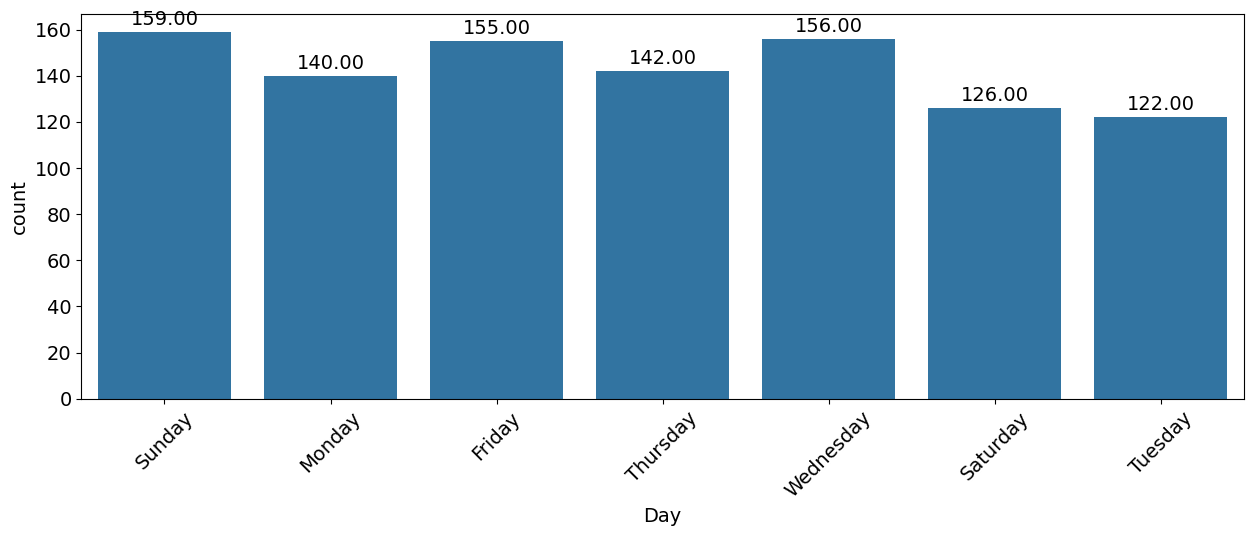

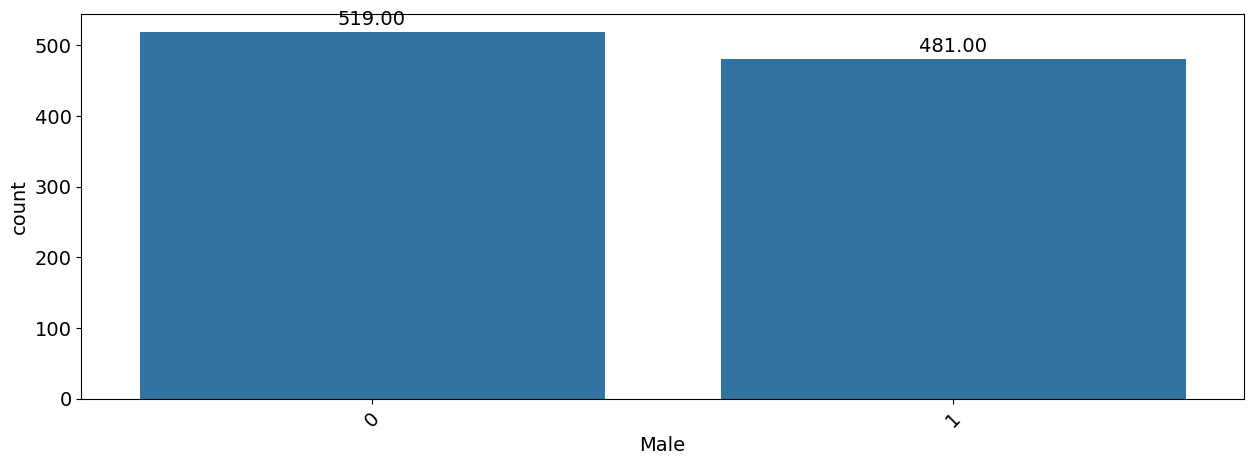

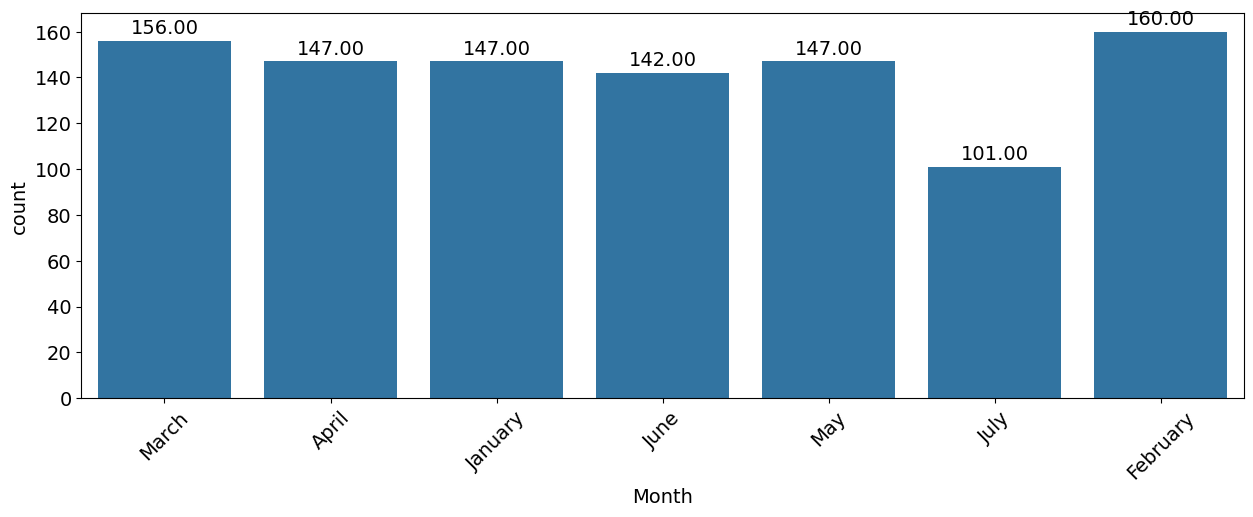

In [76]:
for col in categorical_col:
    plt.figure(figsize=(15, 5))
    ax=sns.countplot(data=df,x=col)
    # Adding annotations
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f'{height:.2f}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points')
    plt.xticks(rotation=45)
    plt.show()

- From these plot we understand that there are some variation present in all of these columns, we need to perform some statistical test to finalize the selected columns.

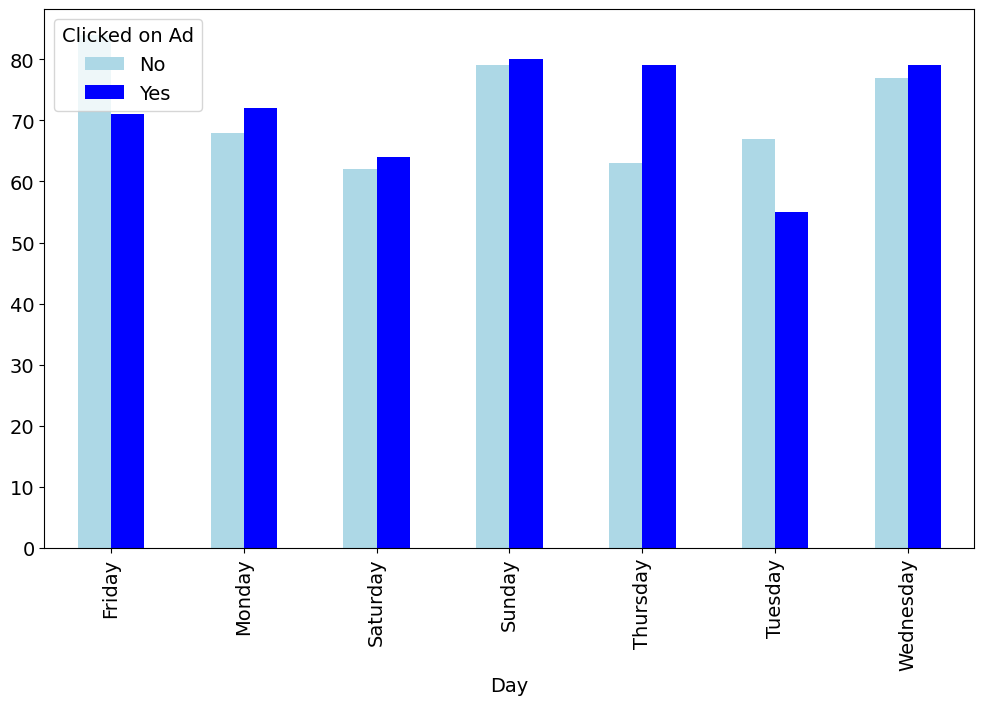

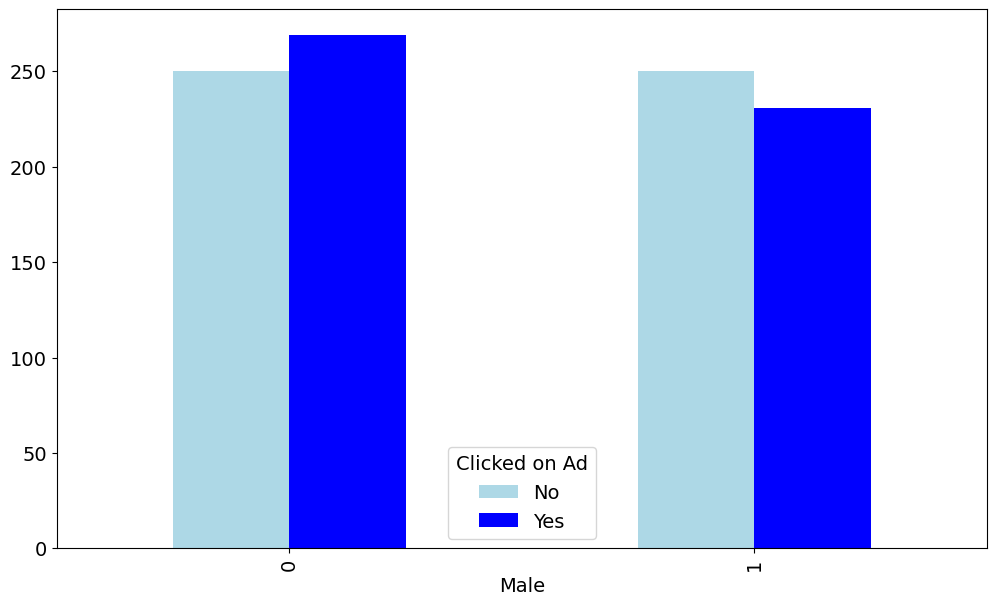

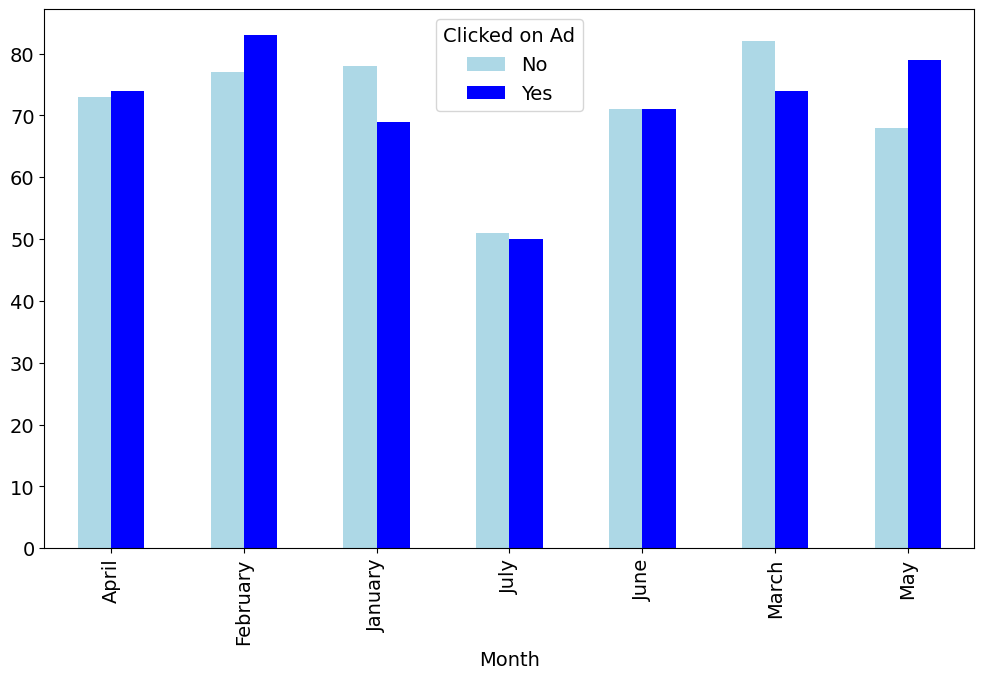

In [79]:
# Creating Grouped bar plots for each categorical predictor against the Target Variable "Clicked"
for col in categorical_col:
    CrossTabResult=pd.crosstab(index=df[col], columns=df["Clicked on Ad"])
    CrossTabResult.plot.bar(color=['lightblue','blue'], figsize=(12,7))
    plt.legend(title='Clicked on Ad', labels=['No', 'Yes'])
    plt.show()

## From above plots we learn that
- In `week_day` columns we see Thursday the clicked is high on the other hand Friday and Tuesday less clicked.
- In `Male` columns we see the similar distribution and clicked rate only count of male visitor are more than female that's why click rate also higher than female.
- In `Month` column we see more visitor in february and may month and similarly the ad click rate also high in those months.

## Statistical Feature Selection (Categorical Vs Categorical) using Chi-Square Test
Chi-Square test is conducted to check the correlation between two categorical variables

* Assumption(H0): The two columns are NOT related to each other
* Result of Chi-Sq Test: The Probability of H0 being True

In [87]:
# Writing a function to find the correlation of all categorical variables with the Target variable
def FunctionChisq(inpData, TargetVariable, CategoricalVariablesList):
    from scipy.stats import chi2_contingency

    # Creating an empty list of final selected predictors
    SelectedPredictors=[]

    print('##### chi-square Results ##### \n')
    for predictor in CategoricalVariablesList:
        CrossTabResult=pd.crosstab(index=inpData[TargetVariable], columns=inpData[predictor])
        ChiSqResult = chi2_contingency(CrossTabResult)

        # If the ChiSq P-Value is <0.05, that means we reject H0, -> p low, null go
        if ( ChiSqResult[1] < 0.05 ):
            SelectedPredictors.append(predictor)
            print(predictor, 'is correlated with', TargetVariable, '| P-Value:', ChiSqResult[1])
        else:
            print(predictor, 'is NOT correlated with', TargetVariable, '| P-Value:', ChiSqResult[1])

    #return(SelectedPredictors)
    return CrossTabResult

In [89]:
temp = FunctionChisq(inpData=df,
              TargetVariable="Clicked on Ad",
              CategoricalVariablesList= categorical_col)

##### chi-square Results ##### 

Day is NOT correlated with Clicked on Ad | P-Value: 0.64269255037449
Male is NOT correlated with Clicked on Ad | P-Value: 0.2546019035670961
Month is NOT correlated with Clicked on Ad | P-Value: 0.9172816839796131


- We see that none of them are imporatant varibles, so when we build the model we'll take all of them the reason for it - individualy they might not any effect on the target variable but combine of two or more variable can impact on target variable.

## Visual exploration (Continuous Vs Categorical) -- Histogram and Box/Violin Plots
When the target variable is Categorical and the predictor is also Continuous then we explore the correlation between them visually using Histogram and Box Plots or Violin Plots.

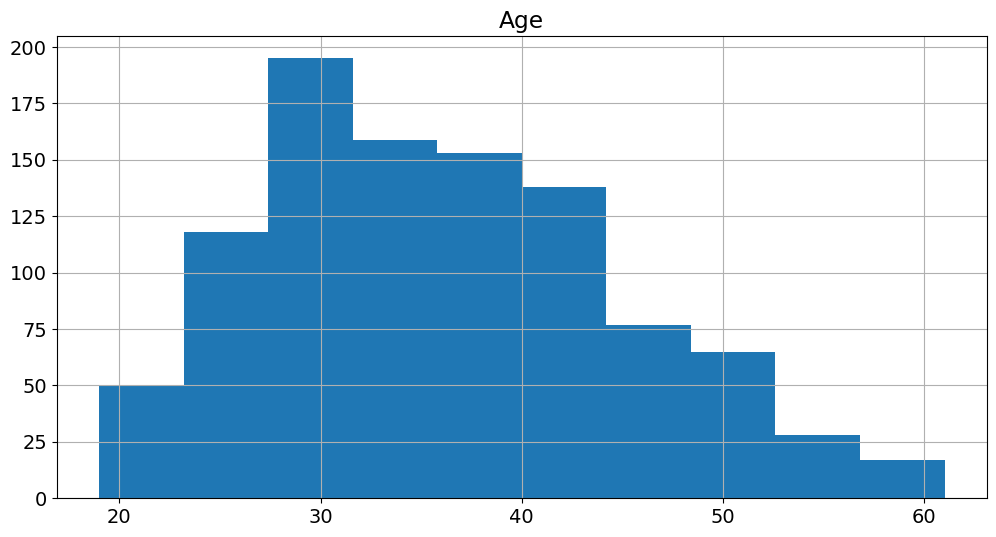

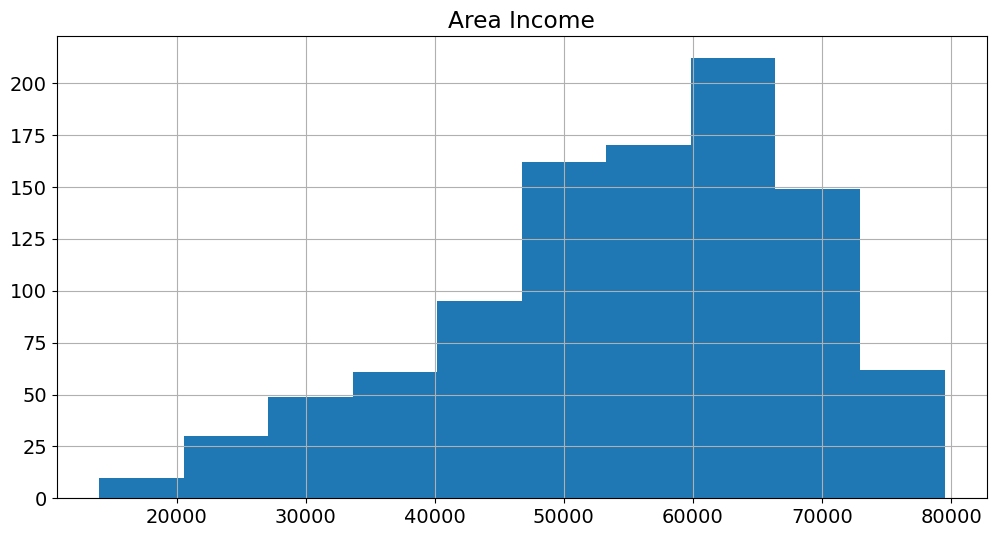

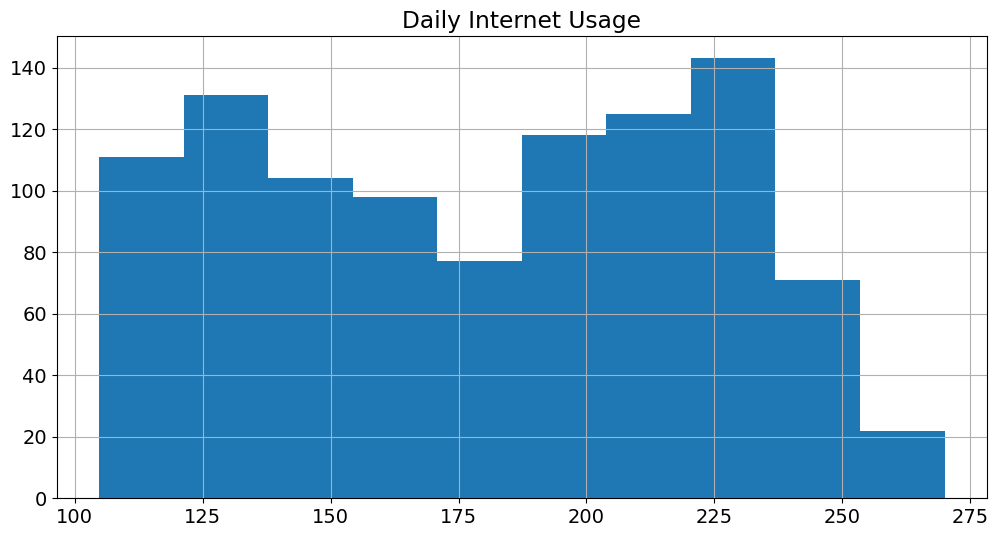

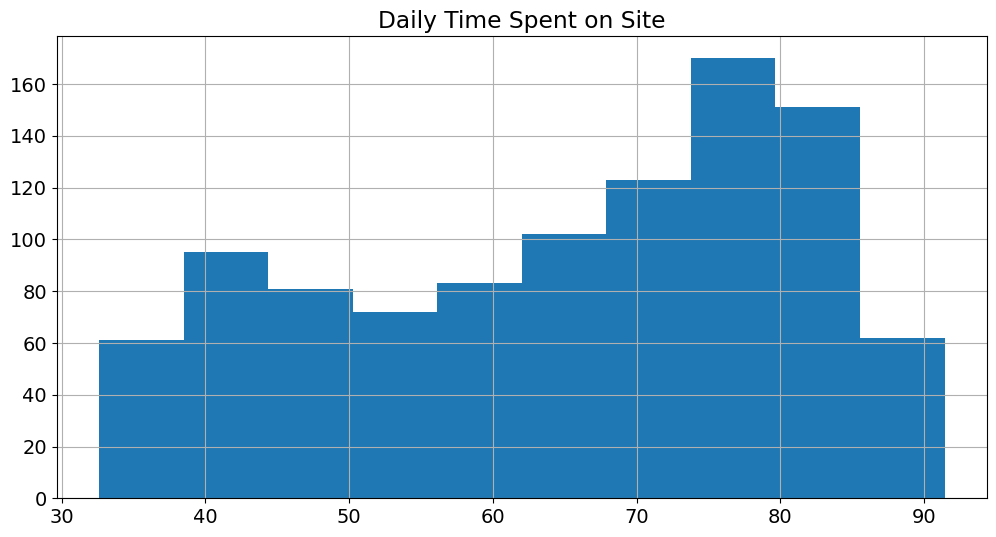

In [93]:
for col in numerical_col:
    df.hist(col, figsize=(12,6))
    plt.show()

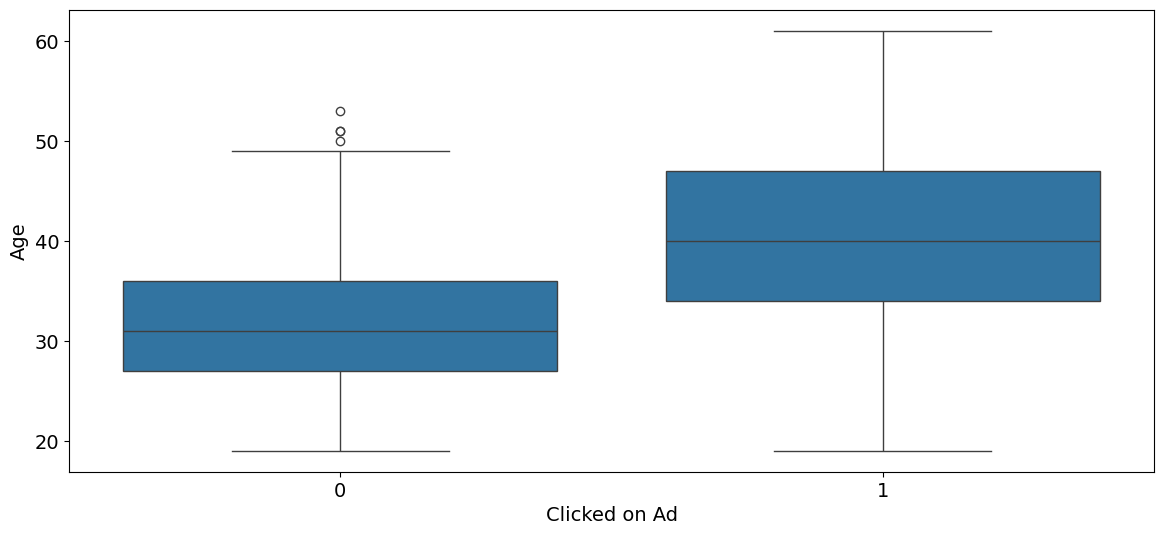

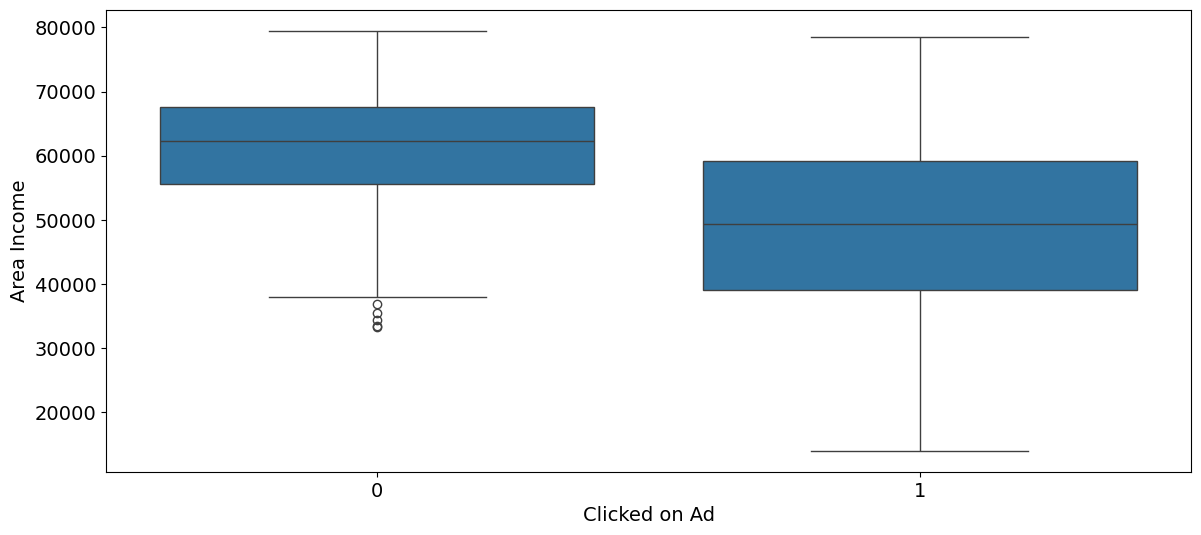

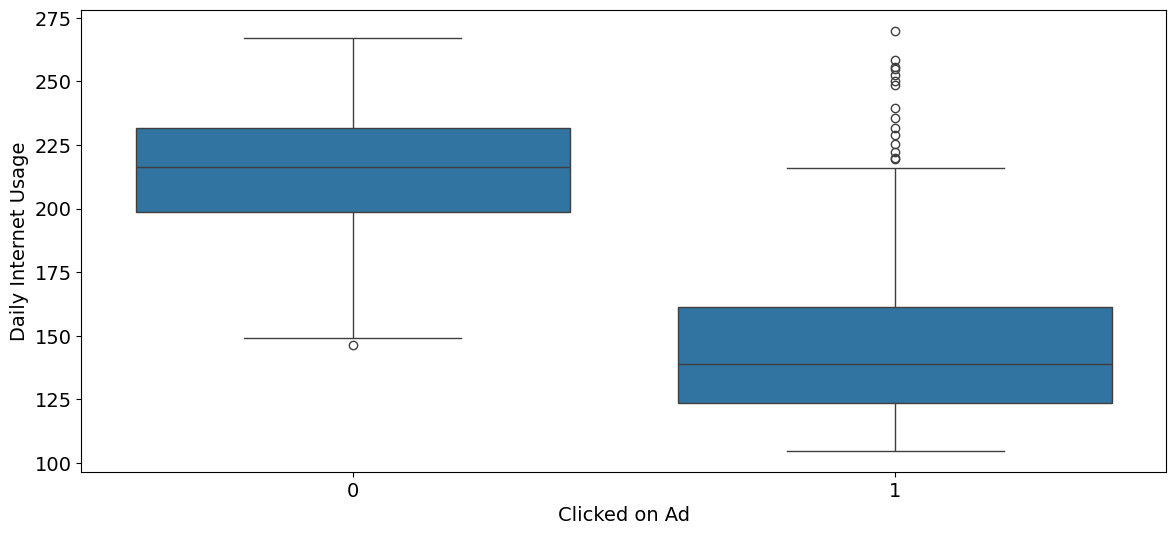

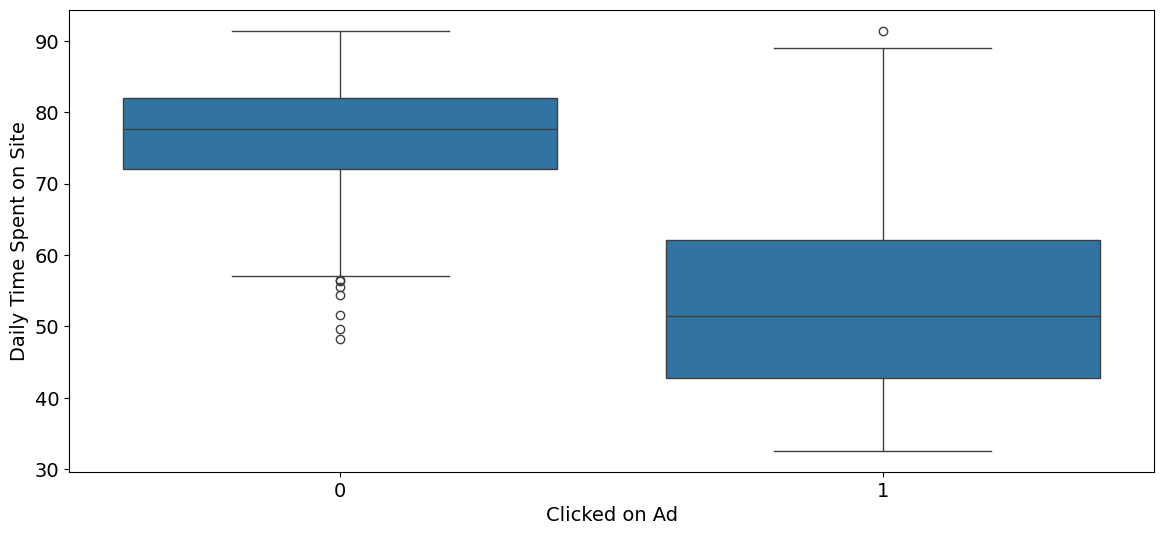

In [95]:
for col in numerical_col:
    plt.figure(figsize=(14,6))
    sns.boxplot(x="Clicked on Ad", y=col, data=df)
    plt.show()

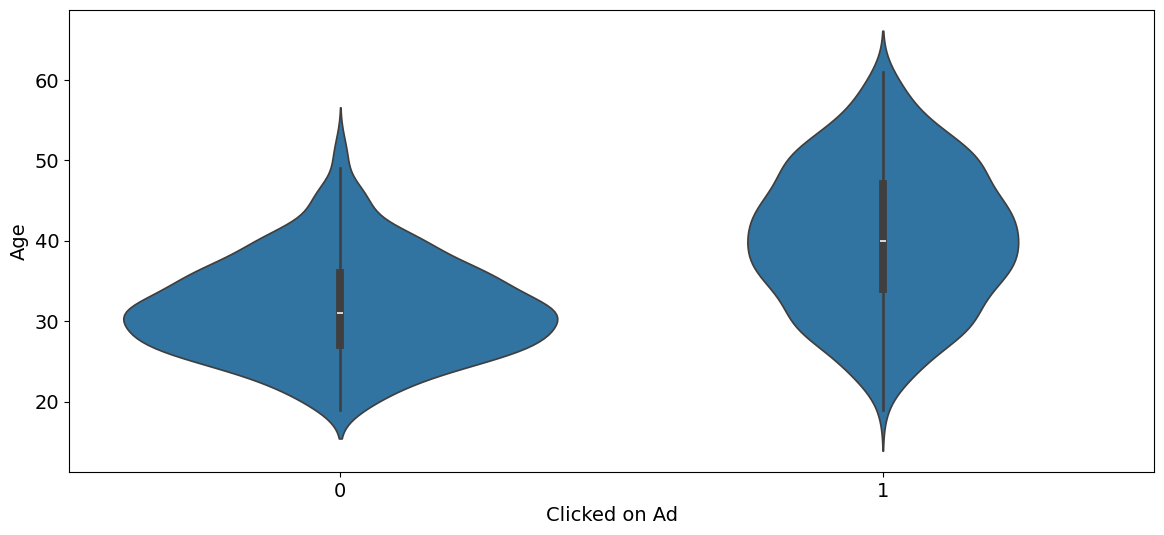

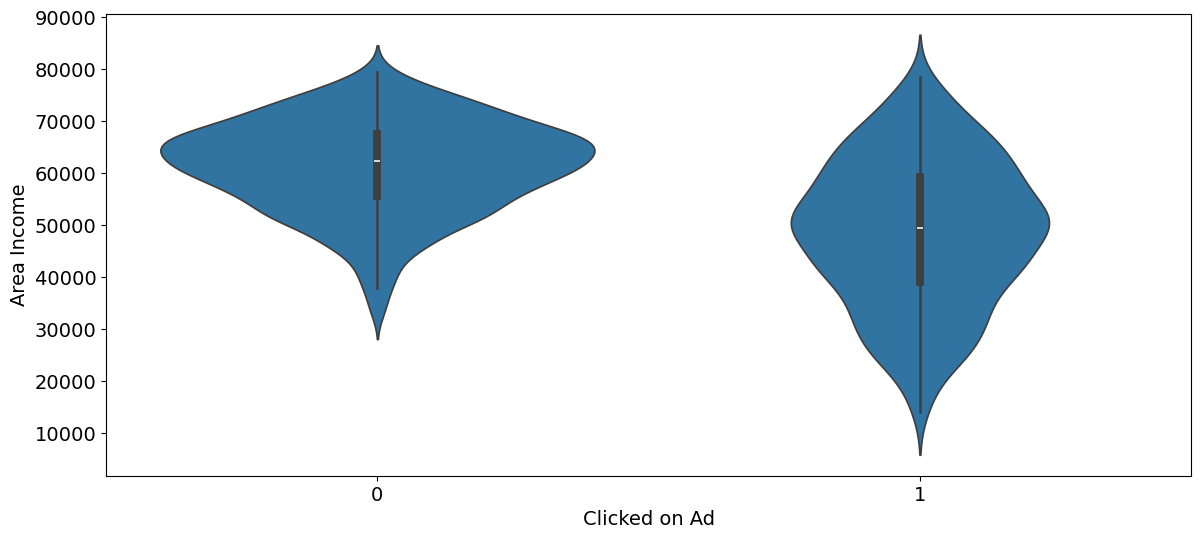

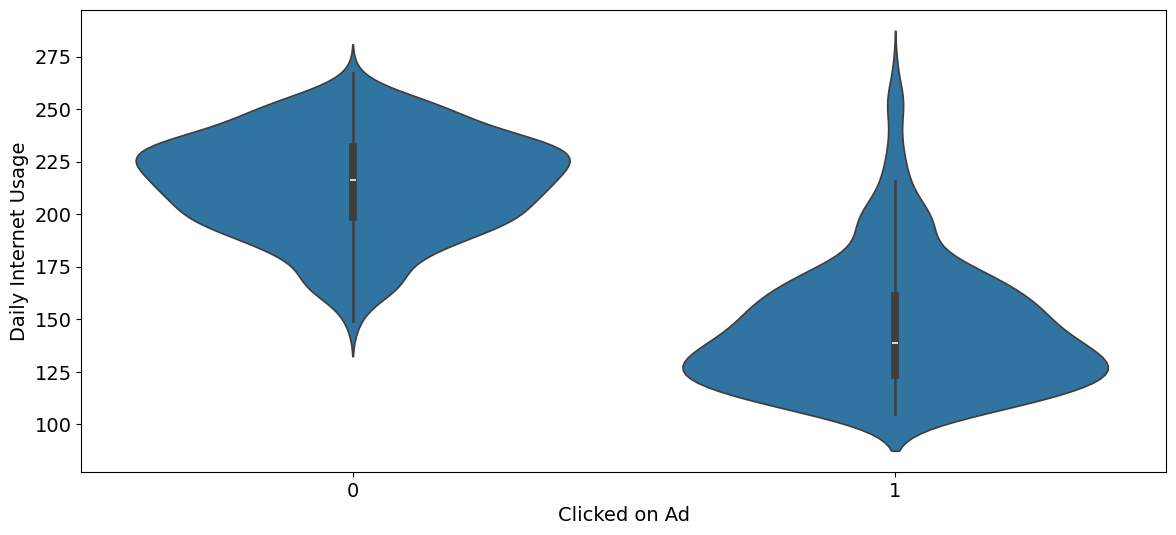

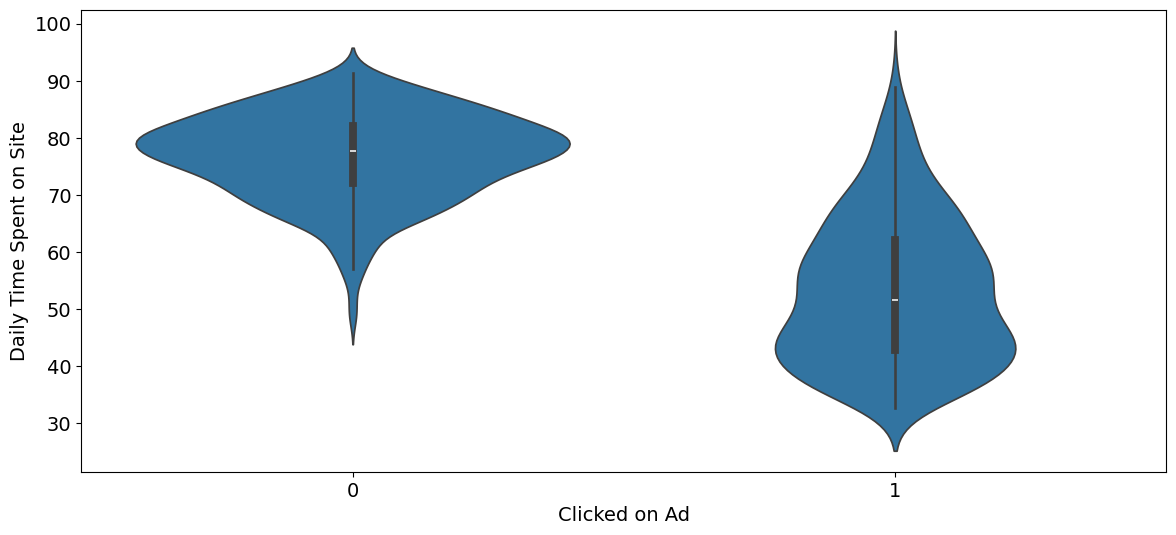

In [97]:
for col in numerical_col:
    plt.figure(figsize=(14,6))
    sns.violinplot(x="Clicked on Ad", y=col, data=df)
    plt.show()

## From above plots we learn that
- In `Age` higher the age less frequently they visited the website and mid-aged people are more frequent clicked the ad.
- In `Avg_Income` the distribution left skewed and higher the income lesser the frequent they clicked the ad.
- In `Internet_Usage` people who spent maximum time in the website are less frequent to clicked the ad.

## Statistical Feature Selection (Categorical Vs Continuous) using ANOVA test
Analysis of variance(ANOVA) is performed to check if there is any relationship between the given continuous and categorical variable

- Assumption(H0): There is NO relation between the given variables (i.e. The average(mean) values of the numeric Predictor variable is same for all the groups in the categorical Target variable)
- ANOVA Test result: Probability of H0 being true

In [103]:
# Defining a function to find the statistical relationship with all the categorical variables
def FunctionAnova(inpData, TargetVariable, ContinuousPredictorList):
    from scipy.stats import f_oneway

    # Creating an empty list of final selected predictors
    SelectedPredictors=[]

    print('##### ANOVA Results ##### \n')
    for predictor in ContinuousPredictorList:
        CategoryGroupLists=inpData.groupby(TargetVariable)[predictor].apply(list)
        AnovaResults = f_oneway(*CategoryGroupLists)

        # If the ANOVA P-Value is <0.05, that means we reject H0
        if (AnovaResults[1] < 0.05):
            print(predictor, 'is correlated with', TargetVariable, '| P-Value:', AnovaResults[1])
            SelectedPredictors.append(predictor)
        else:
            print(predictor, 'is NOT correlated with', TargetVariable, '| P-Value:', AnovaResults[1])

    return (SelectedPredictors)

In [105]:
# Calling the function to check which categorical variables are correlated with target
FunctionAnova(inpData=df, TargetVariable="Clicked on Ad", ContinuousPredictorList=numerical_col)

##### ANOVA Results ##### 

Age is correlated with Clicked on Ad | P-Value: 3.1298083092905155e-62
Area Income is correlated with Clicked on Ad | P-Value: 9.44958341282883e-58
Daily Internet Usage is correlated with Clicked on Ad | P-Value: 3.8932341225400295e-211
Daily Time Spent on Site is correlated with Clicked on Ad | P-Value: 5.8773842441386545e-180


['Age', 'Area Income', 'Daily Internet Usage', 'Daily Time Spent on Site']

- From ANOVA test we saw 'Age', 'Avg_Income', 'Daily Internet Usage' and 'Daily Time Spent on Site' are the variables have some impact on target variable.

## Check Correlation between two variables

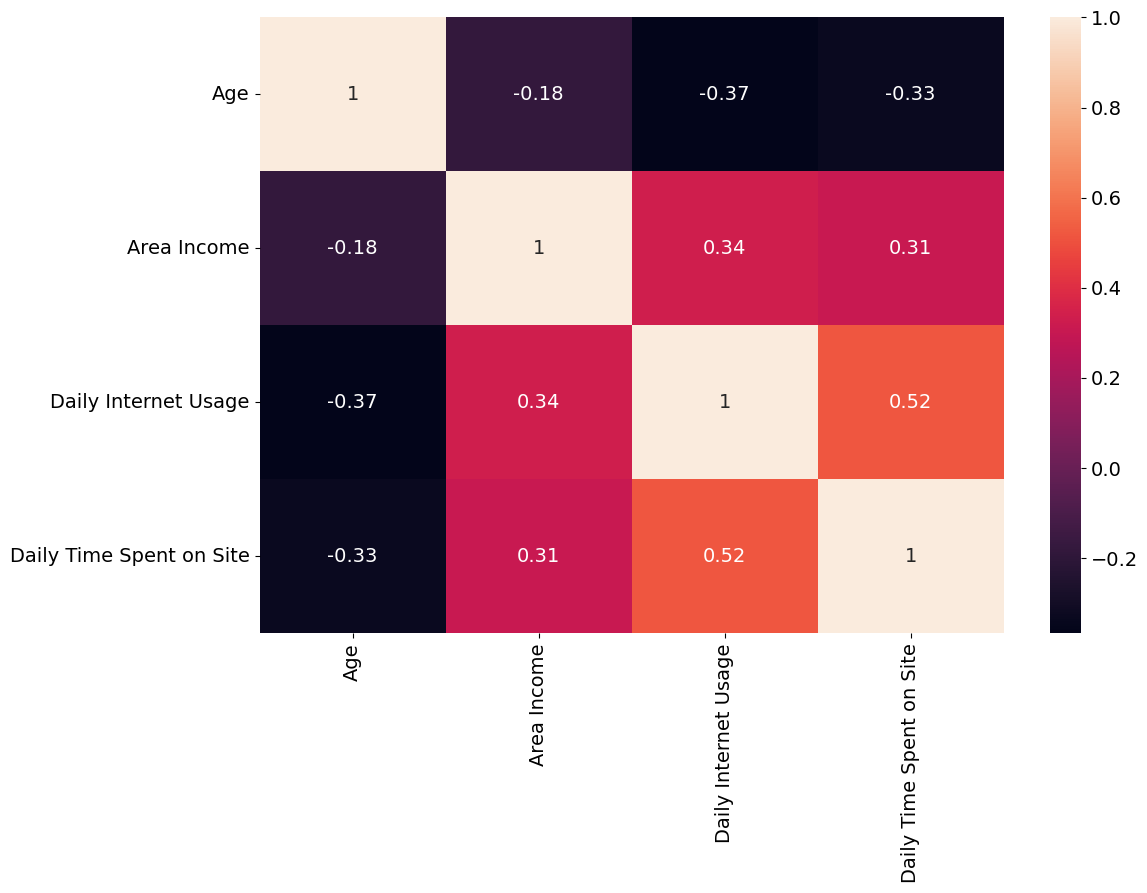

In [109]:
corr_data=df[['Age', 'Area Income', 'Daily Internet Usage', 'Daily Time Spent on Site']]
plt.figure(figsize=(12, 8))
sns.heatmap(corr_data.corr(), annot=True)
plt.show()

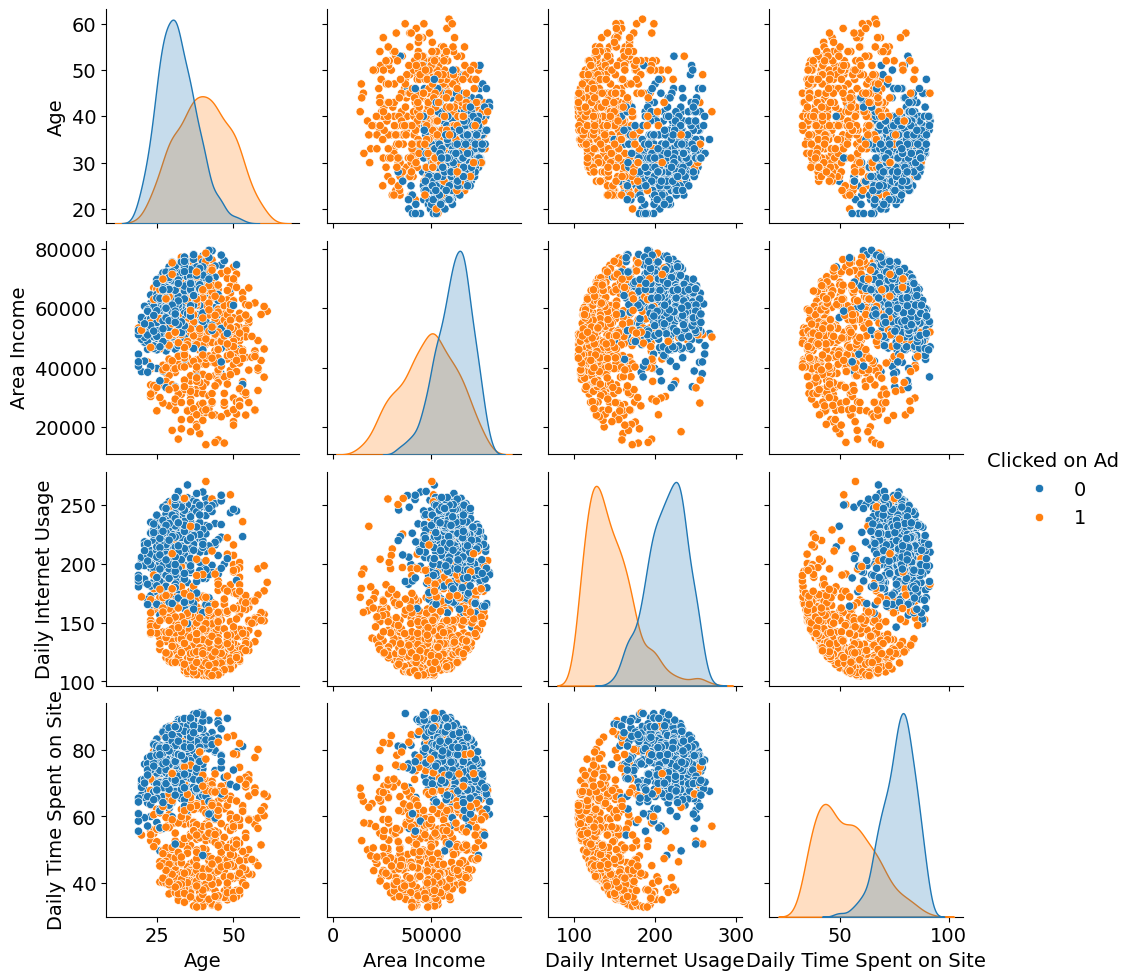

In [112]:
sns.pairplot(data=df[['Age', 'Area Income', 'Daily Internet Usage', 'Daily Time Spent on Site','Clicked on Ad']],hue='Clicked on Ad')
plt.show()

- from these two plot we see that 'Daily Internet Usage' and 'Daily Time Spent on Site' are somewhat correlated each other

## Label Encodeing

In machine learning, we usually deal with datasets that contain multiple labels in one or more than one columns. These labels can be in the form of words or numbers. To make the data understandable or in human-readable form, the training data is often labelled in words.

In [116]:
# apply Label encoder to df_categorical
from sklearn.preprocessing import LabelEncoder

label_encoders = {}
for column in categorical_col:
    label_encoders[column] = LabelEncoder()
    df[column] = label_encoders[column].fit_transform(df[column])

In [118]:
# look at the final data
df.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male,Clicked on Ad,Day,Month,Year
0,68.95,35,61833.90,256.09,0,0,3,5,2016
1,80.23,31,68441.85,193.77,1,0,1,0,2016
2,69.47,26,59785.94,236.50,0,0,3,5,2016
3,74.15,29,54806.18,245.89,1,0,3,2,2016
4,68.37,35,73889.99,225.58,0,0,0,4,2016


## Machine Learning: Splitting the data into Training and Testing sample

In [121]:
from sklearn.model_selection import train_test_split

X = df.drop(['Clicked on Ad'], axis=1)
y = df['Clicked on Ad']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Standardization/Normalization of data
You can choose not to run this step if you want to compare the resultant accuracy of this transformation with the accuracy of raw data.

In [126]:
# pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OrdinalEncoder
from sklearn.compose import make_column_transformer

ct = make_column_transformer(
    (MinMaxScaler(), categorical_col),
    (StandardScaler(), numerical_col),
    remainder='passthrough'
)

X_train = ct.fit_transform(X_train)
X_test = ct.transform(X_test)

In [128]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(800, 8)
(800,)
(200, 8)
(200,)


## Training a Binary Classifier

In [131]:
# import the logistic regression algorithm
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(random_state=0)

# Customisation of your logistic regression model
print(logreg)
logreg.fit(X_train, y_train)

LogisticRegression(random_state=0)


LogisticRegression(random_state=0)

In [133]:
y_pred = logreg.predict(X_test)
f3 = pd.DataFrame(y_pred)
f3['Clicked on Ad'] = y_test.values
print("Accuracy of Logistic Regression is : {}%".format(round(f3.loc[f3[0]==f3['Clicked on Ad']].shape[0] / f3.shape[0] * 100,2)))

Accuracy of Logistic Regression is : 95.5%


- But this is misleading what does 95.0% mean, so remember in logistic regression overall accuracy always misleading.

In [136]:
# import necessary packages to measure model performace
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score, accuracy_score, f1_score, precision_score, recall_score,auc
from sklearn.model_selection import cross_val_score
from scipy import stats

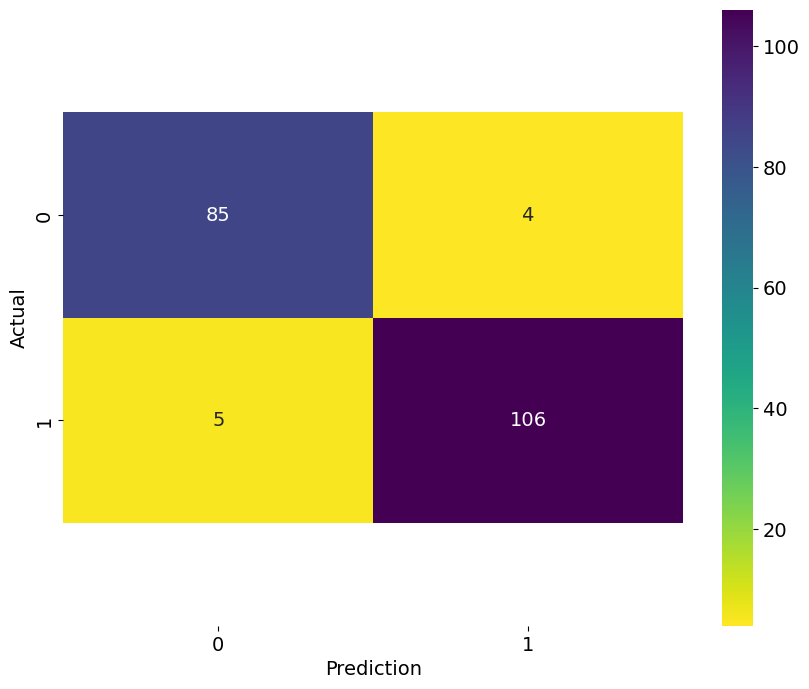

              precision    recall  f1-score   support

           0       0.94      0.96      0.95        89
           1       0.96      0.95      0.96       111

    accuracy                           0.95       200
   macro avg       0.95      0.96      0.95       200
weighted avg       0.96      0.95      0.96       200



In [138]:
# Checking Confusion Metrix
cnf_matrix = confusion_matrix(y_test, y_pred)

# confusion metrics
plt.figure(figsize=(10,8))
ax = sns.heatmap(pd.DataFrame(cnf_matrix), annot = True, cmap = 'viridis_r', fmt = 'd')
bottom, top = ax.get_ylim()
ax.set_ylim(bottom + 0.5, top - 0.5)
plt.xlabel('Prediction')
plt.ylabel('Actual')
plt.show()

print(classification_report(y_test, y_pred))

## Precision / Recall Tradeoff

Increasing precision reduced recall and vice versa

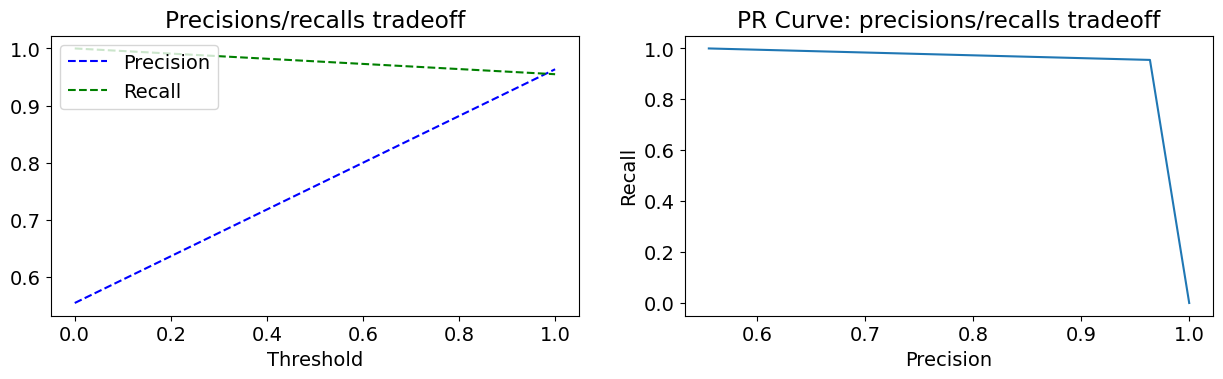

In [141]:
from sklearn.metrics import precision_recall_curve

def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
    plt.plot(thresholds, recalls[:-1], "g--", label="Recall")
    plt.xlabel("Threshold")
    plt.legend(loc="upper left")
    plt.title("Precisions/recalls tradeoff")

precisions, recalls, thresholds = precision_recall_curve(y_test, logreg.predict(X_test))

plt.figure(figsize=(15, 8))
plt.subplot(2, 2, 1)
plot_precision_recall_vs_threshold(precisions, recalls, thresholds)

plt.subplot(2, 2, 2)
plt.plot(precisions, recalls)
plt.xlabel("Precision")
plt.ylabel("Recall")
plt.title("PR Curve: precisions/recalls tradeoff")
plt.show()

With this chart, you can select the threshold value that gives you the best precision/recall tradeoff for your task.

Some tasks may call for higher precision (accuracy of positive predictions). Like designing a classifier that picks up adult contents to protect kids. This will require the classifier to set a high bar to allow any contents to be consumed by children.

Some tasks may call for higher recall (ratio of positive instances that are correctly detected by the classifier). Such as detecting shoplifters/intruders on surveillance images - Anything that remotely resemble "positive" instances to be picked up.

<h2>The Receiver Operating Characteristics (ROC) Curve</h2>

Instead of plotting precision versus recall, the ROC curve plots the `true positive rate` (another name for recall) against the `false positive rate`. The `false positive rate` (FPR) is the ratio of negative instances that are incorrectly classified as positive. It is equal to one minus the `true negative rate`, which is the ratio of negative instances that are correctly classified as negative.

The TNR is also called `specificity`. Hence the ROC curve plots `sensitivity` (recall) versus `1 - specificity`.

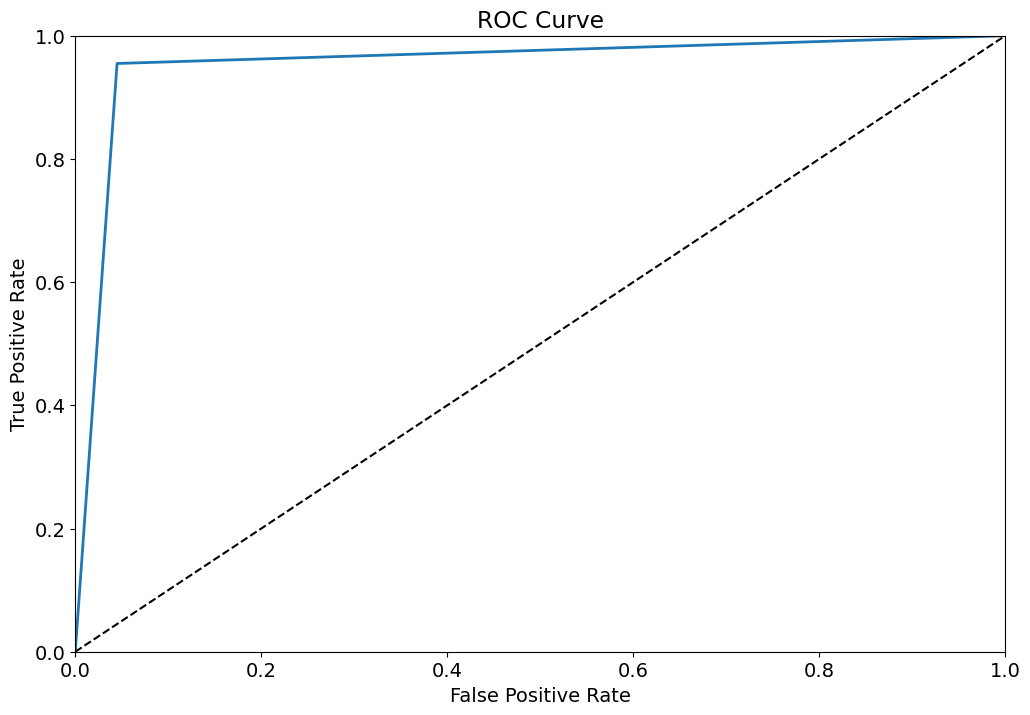

In [145]:
from sklearn.metrics import roc_curve

def plot_roc_curve(fpr, tpr, label=None):
    plt.plot(fpr, tpr, linewidth=2, label=label)
    plt.plot([0, 1], [0, 1], "k--")
    plt.axis([0, 1, 0, 1])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')

fpr, tpr, thresholds = roc_curve(y_test, logreg.predict(X_test))
plt.figure(figsize=(12,8));
plot_roc_curve(fpr, tpr)
plt.show()

Use PR curve whenever the **positive class is rare** or when you care more about the false positives than the false negatives

Use ROC curve whenever the **negative class is rare** or when you care more about the false negatives than the false positives


In the example above, the ROC curve seemed to suggest that the classifier is good. However, when you look at the PR curve, you can see that there are room for improvement.